In [1]:
import srsly 
data = srsly.read_jsonl("/home/apjanco/projects/misnomer/tests/test_data.jsonl")
data = list(data)

In [2]:
import misnomer

for d in data:
    report = misnomer.score(
                predicted=d['predicted_text'],
                ground_truth=d['ground_truth'],
                )
    d['document_score'] = report.document_score
    d['semantic_error_count'] = report.semantic_error_count
    d['obvious_error_count'] = report.obvious_error_count

/home/apjanco/projects/misnomer/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 11434.97it/s]


In [3]:
import srsly 
srsly.write_jsonl("/home/apjanco/projects/misnomer/tests/test_data_semerr.jsonl", data)


In [1]:
import srsly 
data = srsly.read_jsonl("/home/apjanco/projects/misnomer/tests/test_data_semerr.jsonl")
data = list(data)

In [2]:
data[5]

{'image_path': 5,
 'ground_truth': 'is to be made at a meeting of Labour',
 'predicted_text': 'is to be made at a meeting of Labour',
 'cer': 0.0,
 'wer': 0.0,
 'semantic_error': 0.0,
 'kl_divergence': 0.0,
 'entropy': 2.9802000000000003e-06,
 'mean_gt_rank': 3176.4444444444,
 'top5_accuracy': 0.1111111111,
 'inference_time': 10.3478019238,
 'error': None,
 'document_score': 0.0,
 'semantic_error_count': 0,
 'obvious_error_count': 0}

In [3]:
flagged = [r for r in data if r["document_score"] != 0 or r["semantic_error_count"] != 0]
print(f"{len(flagged)} of {len(data)} documents have semantic errors or document score issues.")

32 of 99 documents have semantic errors or document score issues.


In [4]:
import pandas as pd 
df = pd.DataFrame(flagged)
df

,image_path,ground_truth,predicted_text,cer,wer,semantic_error,kl_divergence,entropy,mean_gt_rank,top5_accuracy,inference_time,error,document_score,semantic_error_count,obvious_error_count
0,3,M Ps tomorrow. Mr. Michael Foot has,MPs tomorrow. Mr. Michael Foot has,2.857143,28.571430,2.463759,23.000000,0.685547,6327.666667,0.000000,14.373969,None,0.617337,1,0
1,4,"Griffiths, M P for Manchester Exchange .","Griffiths, HP for Manchester Exchange.",7.500000,57.142860,0.000000,23.000000,0.000323,4282.800000,0.100000,12.759424,None,0.490533,1,0
2,6,A MOVE to stop Mr. Gaitskell from,A move to stop Mr. Gaitskell from,12.121212,14.285715,0.000000,23.000000,0.392090,5758.454545,0.090909,10.288932,None,1.000000,1,0
3,7,0M P for Manchester Exchange .,014 P for Manchester Exchange.,10.000000,50.000000,0.000000,23.000000,0.000000,5647.285714,0.142857,4.157860,None,0.631716,1,0
4,8,A MOVE to stop Mr. Gaitskell from nominating,A MOVE to stop Mr. Cathell from nominating,9.090909,12.500000,0.000000,23.000000,0.000000,5758.363636,0.090909,6.151536,None,0.563666,1,0
5,9,meeting of Labour 0M Ps tommorow . Mr. Michael,meeting of Labour 017 Mr Komarov. Mr. Michael,19.565217,44.444445,0.000000,23.000000,0.000000,2908.785714,0.071429,6.866878,None,0.506777,2,1
6,10,any more Labour life Peers is to be made at a,any more Labour life Peer is to be made at a,2.222222,9.090909,0.000000,23.000000,0.002417,2777.909091,0.090909,6.318280,None,0.917909,1,0
7,11,Foot has put down a resolution on the subject,Ford has put down a resolution on the subject,4.444445,11.111111,0.708144,6.375000,0.012543,2233.666667,0.111111,5.923038,None,0.243523,1,0
8,14,"Though they may gather some Left-wing support , a","Though they may gather some left-wing support, a",4.081633,33.333334,0.000000,23.000000,0.000201,5802.100000,0.100000,7.436602,None,1.000000,1,0
9,18,large majority of Labour M Ps are likely to,large majority of Labour MPs are likely to,2.325581,22.222222,0.000000,23.000000,0.247314,5571.625000,0.125000,7.867449,None,0.575425,1,0


<Axes: xlabel='semantic_error_count'>

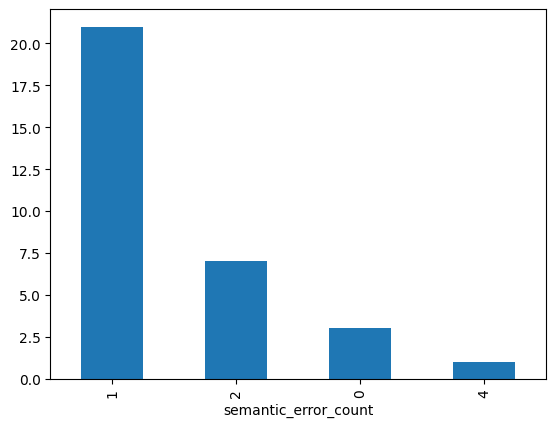

In [5]:
# plot of semantic error count 
df["semantic_error_count"].value_counts().plot(kind="bar")   


<Axes: xlabel='document_score'>

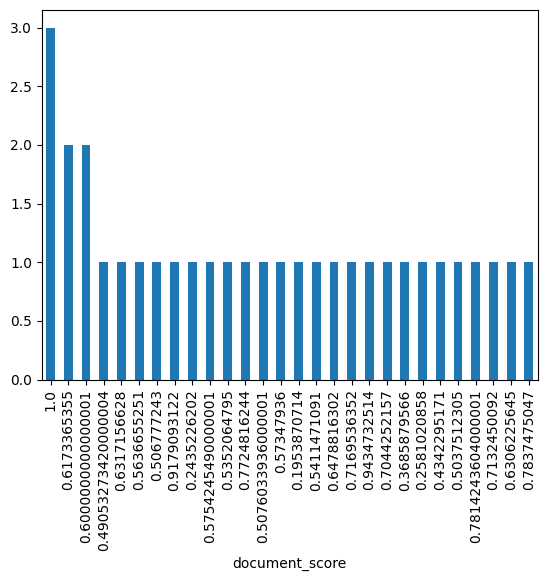

In [6]:
df["document_score"].value_counts().plot(kind="bar")   


In [8]:
df[df['semantic_error_count'] > 1].sort_values(by="document_score")

,image_path,ground_truth,predicted_text,cer,wer,semantic_error,kl_divergence,entropy,mean_gt_rank,top5_accuracy,inference_time,error,document_score,semantic_error_count,obvious_error_count
26,77,"Mr. Iain Macleod , is insisting on a policy of...","Mr. lain Hacleod, is insisting on a policy of ...",7.272727,41.666666,0.000,23.0,0.066895,5209.600000,0.066667,9.892099,None,0.434230,2,0
5,9,meeting of Labour 0M Ps tommorow . Mr. Michael,meeting of Labour 017 Mr Komarov. Mr. Michael,19.565217,44.444445,0.000,23.0,0.000000,2908.785714,0.071429,6.866878,None,0.506777,2,1
13,30,be that as Labour M Ps opposed the,be that as Labour MPs opposed me,8.823530,37.500000,0.000,23.0,0.000028,6804.571429,0.142857,9.981136,None,0.507603,2,0
30,90,"National Independence Party ( 280,000 members )",National Independence Party (280'000 member),8.510638,57.142860,0.000,23.0,0.447021,4301.307692,0.076923,9.074705,None,0.630623,2,0
18,48,Peeresses have been created . Most Labour,Peresses have been created. Most Calour,9.756097,57.142860,2.875,23.0,0.000000,15936.750000,0.000000,10.084203,None,0.647882,2,0
11,25,Though they may gather some Left-wing,Though they may garner some left-wing,8.108108,33.333334,0.000,23.0,0.000036,7823.857143,0.142857,9.926112,None,0.772482,2,0
28,87,opposed to Africans getting an elected,opposed to africans getting and elected,5.263158,33.333334,0.000,23.0,0.003372,12896.714286,0.142857,11.261553,None,0.781424,2,0
31,97,"chief aide , Mr. Julius Greenfield , telephoned","chief vide, mr. julius greenfield, telephoned",12.765957,75.000000,0.000,23.0,0.000001,12946.916667,0.083333,8.900257,None,0.783748,4,0


In [ ]:
# clean dataframe of all records with the ground truth and predicted text side by side

new_df = pd.DataFrame(data)

# show only ground truth and predicted text 
new_df[["ground_truth", "predicted_text"]]

,ground_truth,predicted_text
0,put down a resolution on the subject,put down a resolution on the subject
1,and he is to be backed by Mr. Will,and he is to be backed by Mr. Will
2,nominating any more Labour life Peers,nominating any more Labour life Peers
3,M Ps tomorrow. Mr. Michael Foot has,MPs tomorrow. Mr. Michael Foot has
4,"Griffiths, M P for Manchester Exchange .","Griffiths, HP for Manchester Exchange."
...,...,...
94,and Mr. Harry Nkumbula's African National,and Mr. Harry Nkumbula's African National
95,Delegates from Mr. Kenneth Kaunda's United,Delegates from Mr. Kenneth Kaunda's United
96,Sir Roy is violently opposed to Africans,Sir Roy is violently opposed to Africans getti...
97,"chief aide , Mr. Julius Greenfield , telephoned","chief vide, mr. julius greenfield, telephoned"


In [ ]:
# clean dataframe of all records with the ground truth and predicted labels side by side
